In [1]:
import os as os
import sys
import numpy as np

import warnings
warnings.filterwarnings("ignore", "Wswiglal-redir-stdio")

# adding folders to sys.path
project_root = os.path.abspath(os.path.join(os.getcwd()  , '..', '..'))
if project_root not in sys.path:
    sys.path.insert(0, project_root)

akshat_lisa_root = os.path.abspath(os.path.join(os.getcwd()  , '..',))
if akshat_lisa_root not in sys.path:
    sys.path.insert(0, akshat_lisa_root)

from scripts.readTdi import readTdi, getTdiPath
from scripts.wosa import wosa
from scripts.psdNoise import n_time_noise_from_psd, n_noise_psds, compute_psd_noise_distribution, normalized_psd_residual
from scripts.whitenPsdNoise import n_whitened_time_noises_from_psd, whitened_time_noise_from_psd, n_whiten_noise_psds
from scripts.plot import plot_psd_noise_histogram, plot, plot_orig_and_noise_psds, plot_psd_bias, plot_residual_histogram, plot_median_histogram
from scripts.mle import mle_df
from scripts.medianFuncs import median_exp_pdf, psd_ci, psd_cl
from scripts.plot import plot
from scripts.logpsd import logpsd
import matplotlib.pyplot as plt

In [4]:
# dummy signal:  30 Hz sine + white noise
# fs   = 4096
# T    = 8          # seconds
# t    = np.arange(0, T, 1/fs)
# sig  = np.sin(2*np.pi*30*t) + 0.1*np.random.randn(t.size)

# f_log, P_wosa = logpsd(sig, fs)

# plt.figure(figsize=(6,3))
# plt.loglog(f_log, P_log, ".-")
# plt.xlabel("Frequency [Hz]")
# plt.ylabel("logPSD estimate  [1/Hz]")
# plt.title("BH92 logPSD")
# plt.grid(True, which="both", ls=":")
# plt.show()

In [5]:
#data.size

['L_1', 'L_1', '(0.6)^1 L_1', '(0.6)^2 L_1', '(0.6)^3 L_1', '(0.6)^4 L_1', '(0.6)^5 L_1', '(0.6)^6 L_1', '(0.6)^7 L_1', '(0.6)^8 L_1', '(0.6)^9 L_1', '(0.6)^10 L_1', '(0.6)^11 L_1', '(0.6)^12 L_1', '(0.6)^13 L_1', '(0.6)^14 L_1', '(0.6)^15 L_1', '(0.6)^16 L_1', '(0.6)^17 L_1', '(0.6)^18 L_1', '(0.6)^19 L_1', '(0.6)^20 L_1', '(0.6)^21 L_1', '(0.6)^22 L_1', '(0.6)^23 L_1']
Lk_list: [1000000, 1000000, 600000, 360000, 215999, 129600, 77759, 46655, 27993, 16796, 10077, 6046, 3627, 2176, 1306, 783, 470, 282, 169, 101, 60, 36, 21, 13]
fk_list: [8e-07, 8e-07, 1.3333333333333334e-06, 2.222222222222222e-06, 3.7037208505594935e-06, 6.172839506172839e-06, 1.0288198150696383e-05, 1.7147143928839354e-05, 2.8578573214732255e-05, 4.763038818766373e-05, 7.938870695643544e-05, 0.00013231888852133642, 0.00022056796250344637, 0.0003676470588235294, 0.0006125574272588055, 0.0010217113665389529, 0.001702127659574468, 0.0028368794326241137, 0.004733727810650888, 0.007920792079207921, 0.013333333333333334, 0.

(<Figure size 1000x400 with 2 Axes>,
 array([<Axes: title={'center': 'Time series'}, xlabel='Time [s]', ylabel='TDI-X'>,
        <Axes: xlabel='Frequency [Hz]', ylabel='PSD (LISA)'>],
       dtype=object))

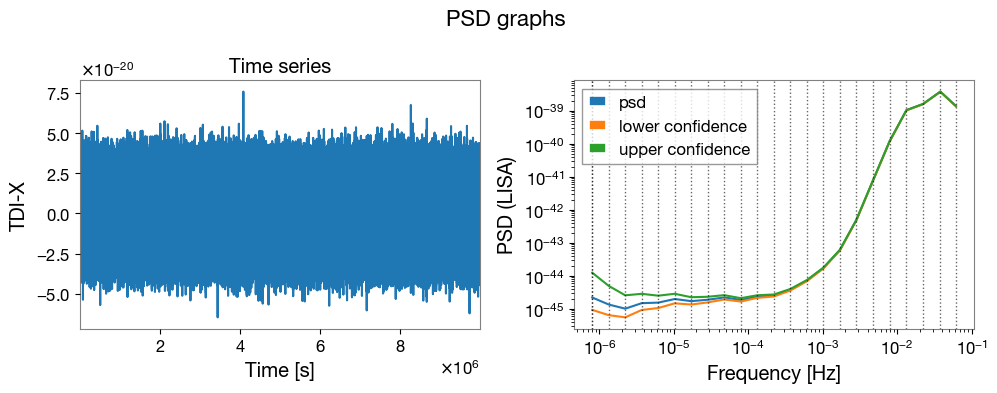

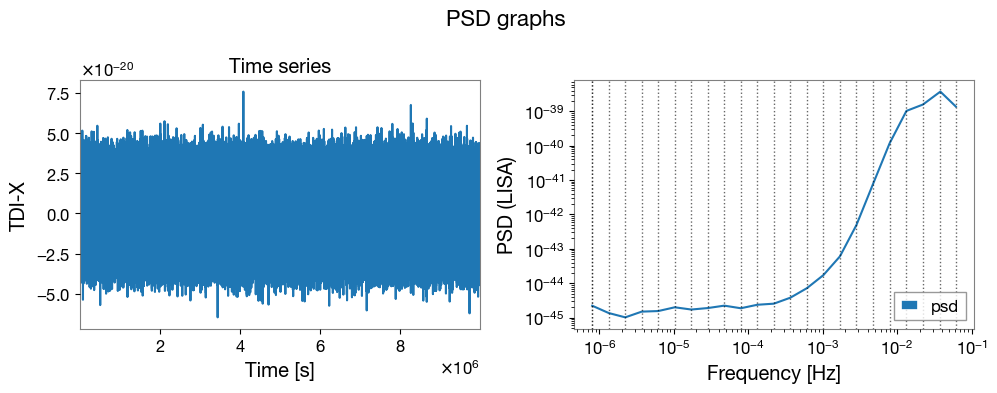

In [6]:
import matplotlib.pyplot as plt

tdi_path = getTdiPath('vsmall_glitch_vlong_tdi.h5')
data, fs, t = readTdi(tdi_path)
f_log, psd_log, nseg = logpsd(x=data, fs=fs, overlap=0, L1=1000000)
psd_log_lower, psd_log_upper = psd_ci(psd_log, nseg, c=0.1)
plot(
    data=data, 
    t=t,
    fs=fs, 
    f=f_log, 
    psd=[psd_log, psd_log_lower, psd_log_upper], 
    nper=20000, 
    title="TDI-X", 
    bigtitle="PSD graphs",
    labels=["psd", "lower confidence", "upper confidence"],
    vlines=f_log,
    # logpsd=True
)

plot(
    data=data, 
    t=t,
    fs=fs, 
    f=f_log, 
    psd=[psd_log], 
    nper=20000, 
    title="TDI-X", 
    bigtitle="PSD graphs",
    labels=["psd"],
    vlines=f_log,
    # logpsd=True
)

# plt.plot(f_log, psd_log)
# plt.yscale('log')

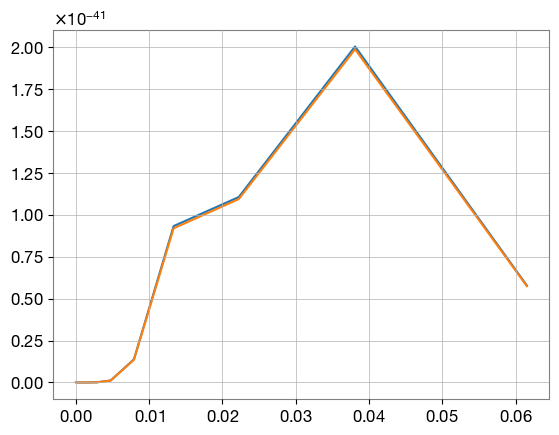

In [7]:
plt.plot(f_log, psd_log_upper-psd_log)
plt.plot(f_log, psd_log-psd_log_lower)

In [8]:
print(psd_log_upper)
print(psd_log)
print(psd_log_lower)

[1.24644130e-44 1.24644130e-44 4.97560467e-45 2.57850566e-45
 2.85662271e-45 2.51300222e-45 2.86571486e-45 2.25575060e-45
 2.32862747e-45 2.60430156e-45 2.10924926e-45 2.58967232e-45
 2.72757137e-45 4.00534769e-45 7.46796618e-45 1.77820695e-44
 6.16742533e-44 5.00579008e-43 7.71199812e-42 1.18544065e-40
 1.03723519e-39 1.58697048e-39 3.76386012e-39 1.38076205e-39]
[2.21468632e-45 2.21468632e-45 1.35616979e-45 1.01600836e-45
 1.49027707e-45 1.54906993e-45 1.99248865e-45 1.71534422e-45
 1.89345485e-45 2.22444551e-45 1.86889239e-45 2.35973273e-45
 2.53929730e-45 3.79052854e-45 7.15682702e-45 1.72072939e-44
 6.01273546e-44 4.90842077e-43 7.59576178e-42 1.17161795e-40
 1.02790817e-39 1.57591198e-39 3.74382148e-39 1.37497683e-39]
[9.33705552e-46 9.33705552e-46 6.46226612e-46 5.54982384e-46
 9.29187328e-46 1.06166194e-45 1.47581243e-45 1.35428480e-45
 1.57409901e-45 1.92524730e-45 1.66910881e-45 2.16046054e-45
 2.37076078e-45 3.59335995e-45 6.86568216e-45 1.66613270e-44
 5.86408686e-44 4.8140

(<Figure size 1000x400 with 2 Axes>,
 array([<Axes: title={'center': 'Time series'}, xlabel='Time [s]', ylabel='TDI-X'>,
        <Axes: xlabel='Frequency [Hz]', ylabel='PSD (LISA)'>],
       dtype=object))

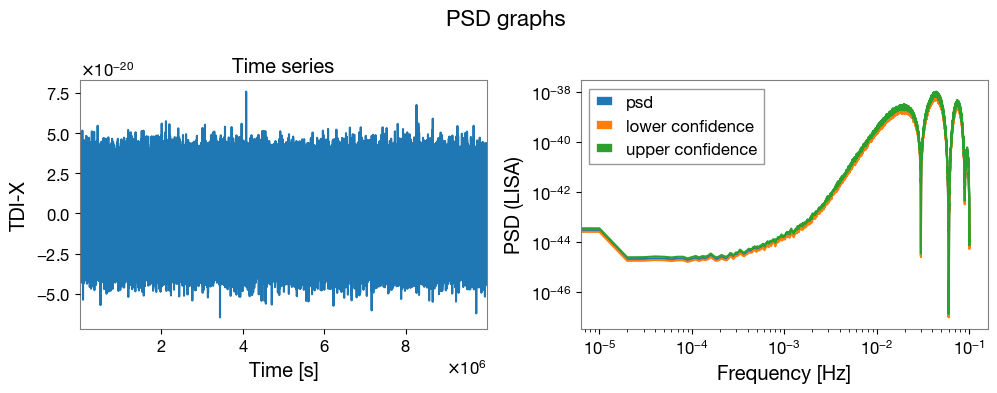

In [2]:
tdi_path = getTdiPath('vsmall_glitch_vlong_tdi.h5')
data, fs, t = readTdi(tdi_path)
f_wosa, psd_wosa, _, nseg = wosa(x=data, fs=fs, nperseg=20000, noverlap=0)
psd_wosa_lower, psd_wosa_upper = psd_ci(psd_wosa, nseg, c=0.1)

plot(
    data=data, 
    t=t,
    fs=fs, 
    f=f_wosa, 
    psd=[psd_wosa, psd_wosa_lower, psd_wosa_upper], 
    nper=20000, 
    title="TDI-X", 
    bigtitle="PSD graphs",
    labels=["psd", "lower confidence", "upper confidence"]
)

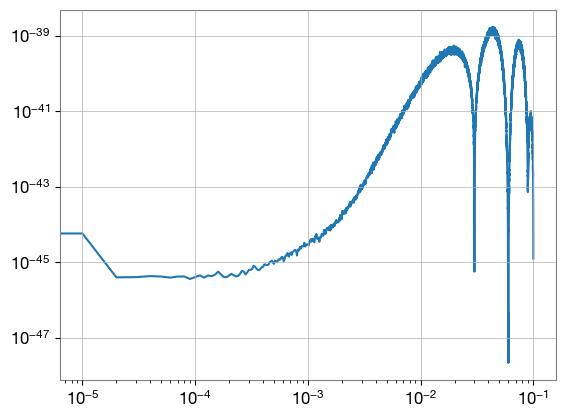

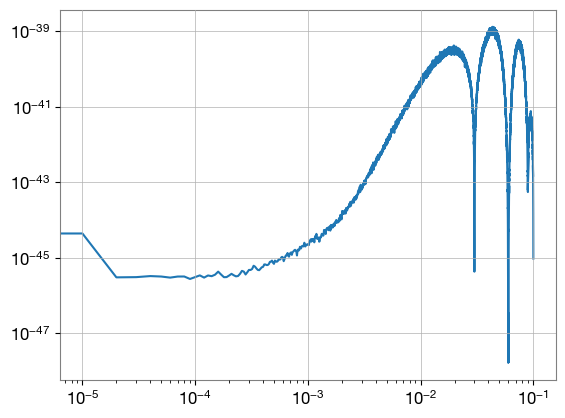

In [3]:
plt.plot(f_wosa, psd_wosa_upper - psd_wosa)
plt.xscale("log")
plt.yscale("log")
plt.show()

plt.plot(f_wosa, psd_wosa - psd_wosa_lower)
plt.xscale("log")
plt.yscale("log")
plt.show()

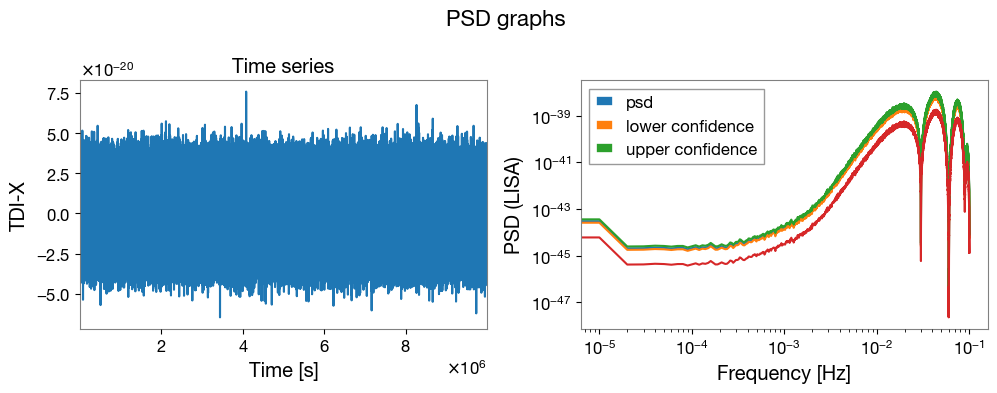

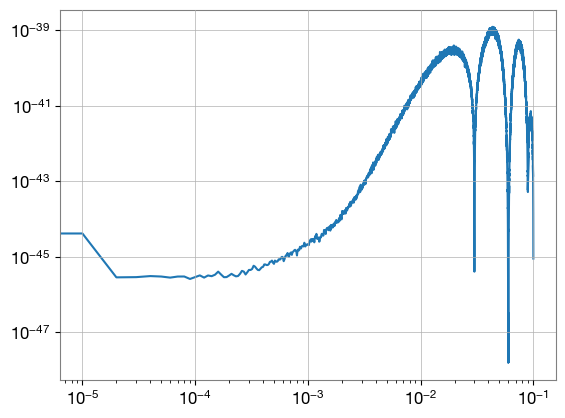

In [4]:
psd_wosa_lower, psd_wosa_upper = psd_cl(psd_wosa, nseg, c=0.1)
plot(
    data=data, 
    t=t,
    fs=fs, 
    f=f_wosa, 
    psd=[psd_wosa, psd_wosa_lower, psd_wosa_upper], 
    nper=20000, 
    title="TDI-X", 
    bigtitle="PSD graphs",
    labels=["psd", "lower confidence", "upper confidence"]
)

plt.plot(f_wosa, psd_wosa_upper - psd_wosa)
plt.xscale("log")
plt.yscale("log")
plt.show()

plt.plot(f_wosa, psd_wosa - psd_wosa_lower)
plt.xscale("log")
plt.yscale("log")
plt.show()